# Hot Hand, Real or Believed?

This notebook contains the full analysis pipeline used in the project. Data Volley (.dvw) files are parsed using the open-source pydatavolley library, then cleaned and analyzed using mixed-effects logistic regression.

The analysis addresses three research questions:

* RQ1 — Actual hot hand: Is there evidence of a real hot-hand effect?
* RQ2 — Believed hot hand: Does the setter behave as if she believes in the hot hand?
* RQ3 — Score pressure: Does score pressure affect attacking decisions?

## What pydatavolley does and what is added in the notebook

pydatavolley reads the raw .dvw files and returns a structured table with information about each action, including team, player, skill, evaluation, score, rotation, and attack combination code.

The notebook adds three elements needed for the analysis:

* a stable match ID instead of the randomly generated one
* an own_team flag based on the team name
* attack tempo (quick/super/medium/high/setter tip), decoded from the attack combination code

### Dataset :

- **Source:** 63 DataVolley `.dvw` files (Italian Women's Serie A2, 2025/26)
- **Location:** Google Drive https://drive.google.com/drive/folders/12FB14d8SB7hSl-3QAnBUYOFK3_G75XlP?usp=share_link

### Github repository :

- Repository

## References

- openvolley (datavolley): https://github.com/openvolley/datavolley.git
- openvolley (pydatavolley): https://github.com/openvolley/pydatavolley.git
- manual: https://openvolley.r-universe.dev/datavolley/doc/manual.html$0

## 1. Setup

In [21]:
!pip install pydatavolley --quiet

import pandas as pd
import numpy as np
import os, glob
from datavolley import read_dv
from charset_normalizer import from_path

pd.set_option('display.max_columns', 60)
np.random.seed(42)
print("Setup done")

Setup done


## 2. Load the data from Google Drive

In [22]:
from google.colab import drive
drive.mount('/content/drive')

dvw_folder = "/content/drive/MyDrive/database_datavolley"

dvw_files = glob.glob(os.path.join(dvw_folder, '**', '*.dvw'), recursive=True)
print(f"Found {len(dvw_files)} file .dvw in {dvw_folder}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 63 file .dvw in /content/drive/MyDrive/database_datavolley


## 3. Compatibility setup

The current Google Colab environment uses newer versions of NumPy and pandas than those used to develop pydatavolley. This can cause some compatibility errors when parsing the .dvw files.

Before parsing, a few runtime fixes are applied to handle changes in missing values, deprecated NumPy aliases, and some pandas/NumPy operations. The Python recursion limit is also increased for a small number of files that require deeper internal operations.

These changes only ensure compatibility with the current Colab environment and do not modify the original .dvw data.

In [23]:
import inspect, importlib, os, glob, re
import datavolley.read_dv as _read_dv_module

_pkg_dir = os.path.dirname(inspect.getfile(_read_dv_module))

# Patch 1: NumPy >=2.0 dtype promotion
# Replace np.nan with None across the package to avoid string/NaN type conflicts
_nan_token_pattern = re.compile(r"\bnp\.nan\b")
_total_dtype_fixes = 0
for _py_file in glob.glob(os.path.join(_pkg_dir, '*.py')):
    with open(_py_file, encoding='utf-8') as _f:
        _content = _f.read()
    _new_content, _n = _nan_token_pattern.subn("None", _content)
    if _n:
        with open(_py_file, 'w', encoding='utf-8') as _f:
            _f.write(_new_content)
        _total_dtype_fixes += _n

if _total_dtype_fixes:
    print(f"Patch 1: fixed {_total_dtype_fixes} NumPy dtype issues in pydatavolley.")
else:
    print("Patch 1: no fix needed")

# Patch 2: pandas >=3.0 chained assignment
# Fix chained fillna(..., inplace=True) calls across the pydatavolley package
_chain_pattern = re.compile(r"(\w+)\['(\w+)'\]\.fillna\(([^,\n]+), inplace=True\)")
_total_fixes = 0
for _py_file in glob.glob(os.path.join(_pkg_dir, '*.py')):
    with open(_py_file, encoding='utf-8') as _f:
        _content = _f.read()
    _new_content, _n = _chain_pattern.subn(
        lambda m: f"{m.group(1)}.fillna({{'{m.group(2)}': {m.group(3)}}}, inplace=True)",
        _content
    )
    if _n:
        with open(_py_file, 'w', encoding='utf-8') as _f:
            _f.write(_new_content)
        _total_fixes += _n

if _total_fixes:
    print(f"Patch 2: fixed {_total_fixes} occurrences in the installed pydatavolley package.")
else:
    print("Patch 2: no fix needed")

# Patch 3: np.NaN was removed in NumPy 2.0
# Replace it with np.nan across the pydatavolley package
_nan_pattern = re.compile(r"\bnp\.NaN\b")
_total_nan_fixes = 0
for _py_file in glob.glob(os.path.join(_pkg_dir, '*.py')):
    with open(_py_file, encoding='utf-8') as _f:
        _content = _f.read()
    _new_content, _n = _nan_pattern.subn("np.nan", _content)
    if _n:
        with open(_py_file, 'w', encoding='utf-8') as _f:
            _f.write(_new_content)
        _total_nan_fixes += _n

if _total_nan_fixes:
    print(f"Patch 3: fixed {_total_nan_fixes} occurrences in the installed pydatavolley package.")
else:
    print("Patch 3: no fix needed")

# Patch 4: NumPy safety fallback for np.where/np.select
# Handles any remaining string/NaN type conflicts only when the original call fails
import numpy as np

def _looks_like_bare_nan(v):
    try:
        return isinstance(v, float) and np.isnan(v)
    except TypeError:
        return False

# Idempotency check: avoid patching np.where more than once
# This prevents infinite recursion if the cell is run again in the same session
if not getattr(np.where, '_is_dtype_safe_wrapper', False):
    _original_where = np.where
    def _safe_where(condition, *args):
        try:
            return _original_where(condition, *args)
        except TypeError as e:
            if 'could not be promoted' not in str(e):
                raise
            # Build the fallback result directly with dtype "object" instead of retrying
            # _original_where. This also prevents recursion in the fallback path
            if len(args) == 2:
                x, y = args
                cond_arr = np.asarray(condition)
                out = np.empty(cond_arr.shape, dtype=object)
                out[:] = y
                out[cond_arr] = x
                return out
            fixed_args = tuple(None if _looks_like_bare_nan(a) else a for a in args)
            return _original_where(condition, *fixed_args)
    _safe_where._is_dtype_safe_wrapper = True
    np.where = _safe_where

if not getattr(np.select, '_is_dtype_safe_wrapper', False):
    _original_select = np.select
    def _safe_select(condlist, choicelist, default=0):
        try:
            return _original_select(condlist, choicelist, default=default)
        except TypeError as e:
            if 'could not be promoted' not in str(e):
                raise
            fixed_choicelist = [None if _looks_like_bare_nan(c) else c for c in choicelist]
            fixed_default = None if _looks_like_bare_nan(default) else default
            return _original_select(condlist, fixed_choicelist, default=fixed_default)
    _safe_select._is_dtype_safe_wrapper = True
    np.select = _safe_select

print("Patch 4 enabled")

# Patch 5: increase Python's recursion limit for long .dvw files.
# This prevents RecursionError during pydatavolley parsing.
import sys, threading
sys.setrecursionlimit(20000)

# Use a larger thread stack (64 MB) so the higher recursion limit can be
# safely used when parsing long .dvw files
threading.stack_size(64 * 1024 * 1024)
print("Patch 5 enabled")

import datavolley.helpers as _helpers_module
import datavolley.get_players_from_md as _players_module
importlib.reload(_helpers_module)
importlib.reload(_players_module)
importlib.reload(_read_dv_module)
from datavolley import read_dv

# Suppress harmless repeated FutureWarnings from pydatavolley
# The filter only applies to this package, so other warnings remain visible
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='datavolley')

Patch 1: no fix needed
Patch 2: no fix needed
Patch 3: no fix needed
Patch 4 enabled
Patch 5 enabled


## 4. Additional information

Most of the information needed for the analysis is already provided by pydatavolley, including team, player, skill, evaluation, score, set number, attack code, and player rotations.

Three additional variables are created:

1. **Stable match ID**
    
    The random match_id generated by pydatavolley is replaced with the original file name, so each observation can be linked to its match.
2. **Own-team indicator**

    An own_team variable identifies actions performed by Brescia or Talmassons, the two teams considered in the study.
3. **Attack tempo**

    Attack tempo is needed for RQ3 but is not directly available in the standard output. It is decoded from the [3ATTACKCOMBINATION] section of each .dvw file using the attack_code. Attacks are then classified as quick, super, medium, high ball, or setter tip.

In [24]:
OWN_TEAMS = {'Valsabbina Millenium Brescia', 'CDA Volley Talmassons FVG'}

TEMPO_LABEL = {
    'Q': 'quick',
    'N': 'quick',
    'U': 'super',
    'H': 'high',
    'M': 'medium',
    'O': 'other',
}


def get_attack_tempo(rows):
    # Read attack tempo from the [3ATTACKCOMBINATION] section of the .dvw file
    # since pydatavolley does not include it in get_plays()
    idx = rows.index('[3ATTACKCOMBINATION]\n')
    end = rows.index('[3SETTERCALL]\n')
    tempo_by_code = {}
    for line in rows[idx + 1:end]:
        parts = line.strip().split(';')
        if len(parts) > 3 and parts[0]:
            tempo_by_code[parts[0]] = parts[3]
    return tempo_by_code


def process_file(path):
    match_id = os.path.basename(path).replace('.dvw', '')
    dv = read_dv.DataVolley(path)
    df = dv.get_plays().copy()
    df['match_id'] = match_id
    df['team_name'] = df['team']
    df['is_own_team'] = df['team_name'].isin(OWN_TEAMS)

    enc = from_path(path).best().encoding
    with open(path, 'r', encoding=enc) as f:
        rows = f.readlines()
    tempo_map = get_attack_tempo(rows)
    df['tempo'] = df['attack_code'].map(tempo_map)
    df['tempo_label'] = df['tempo'].map(TEMPO_LABEL)

    own_team = dv.home_team if dv.home_team in OWN_TEAMS else (
        dv.visiting_team if dv.visiting_team in OWN_TEAMS else None)
    info = {'file': os.path.basename(path), 'match_id': match_id,
            'home_team': dv.home_team, 'visiting_team': dv.visiting_team,
            'own_team': own_team, 'n_events': len(df)}
    return df, info

## 5. Parsing all Datavolley files

All .dvw files are parsed using pydatavolley and combined into a single dataset containing the scouted actions from all matches.

Each file is processed separately, so any parsing error can be linked to the corresponding match.

The resulting dataset is used for the following data preparation and statistical analyses.

In [25]:
all_rows, match_infos, errors = [], [], []
first_traceback = None

def _parse_all_files():
    global first_traceback
    for f in sorted(dvw_files):
        try:
            df, info = process_file(f)
            all_rows.append(df)
            match_infos.append(info)
        except Exception as e:
            errors.append((f, str(e)))
            if first_traceback is None:
                import traceback
                first_traceback = traceback.format_exc()

_parsing_thread = threading.Thread(target=_parse_all_files)
_parsing_thread.start()
_parsing_thread.join()

print(f"Files processed: {len(dvw_files)} | Successful: {len(all_rows)} | Errors: {len(errors)}")
for e in errors:
    print(" -", e)

if first_traceback:
    print("\nFull traceback of the first error")
    print(first_traceback)

if not all_rows:
    raise RuntimeError(
        "No .dvw files were read successfully"
    )

all_events = pd.concat(all_rows, ignore_index=True)
match_index = pd.DataFrame(match_infos)

print(f"Total events extracted: {len(all_events)}")
print(f"Own-team events: {all_events.is_own_team.sum()}")
all_events.head()

Files processed: 63 | Successful: 63 | Errors: 0
Total events extracted: 93884
Own-team events: 48699


,match_id,video_file_number,video_time,code,team,player_number,player_name,player_id,skill,evaluation_code,setter_position,attack_code,set_code,set_type,start_zone,end_zone,end_subzone,num_players_numeric,home_team_score,visiting_team_score,home_setter_position,visiting_setter_position,custom_code,home_p1,home_p2,home_p3,home_p4,home_p5,home_p6,visiting_p1,visiting_p2,visiting_p3,visiting_p4,visiting_p5,visiting_p6,start_coordinate,mid_coordinate,end_coordinate,point_phase,attack_phase,start_coordinate_x,start_coordinate_y,mid_coordinate_x,mid_coordinate_y,end_coordinate_x,end_coordinate_y,set_number,home_team,visiting_team,home_team_id,visiting_team_id,point_won_by,serving_team,receiving_team,rally_number,possesion_number,team_name,is_own_team,tempo,tempo_label
0,&cifi_talmassons-cbl_brescia,1,515,*P20>LUp,CDA Volley Talmassons FVG,None,NaN,NaN,NaN,None,2,None,None,None,None,None,None,None,<NA>,<NA>,2,6,None,11,10,20,13,1,14,5,13,11,10,16,17,<NA>,<NA>,<NA>,Reception,None,NaN,NaN,NaN,NaN,NaN,NaN,1,CDA Volley Talmassons FVG,C.B.L. Costa Volpino,TAL,CBL,None,NaN,None,0,0,CDA Volley Talmassons FVG,True,NaN,NaN
1,&cifi_talmassons-cbl_brescia,1,515,*z3>LUp,CDA Volley Talmassons FVG,None,NaN,NaN,NaN,None,3,None,None,None,None,None,None,None,<NA>,<NA>,3,6,None,11,10,20,13,1,14,5,13,11,10,16,17,<NA>,<NA>,<NA>,Reception,None,NaN,NaN,NaN,NaN,NaN,NaN,1,CDA Volley Talmassons FVG,C.B.L. Costa Volpino,TAL,CBL,None,NaN,None,0,1,CDA Volley Talmassons FVG,True,NaN,NaN
2,&cifi_talmassons-cbl_brescia,1,515,aP05>LUp,C.B.L. Costa Volpino,None,NaN,NaN,NaN,None,6,None,None,None,None,None,None,None,<NA>,<NA>,3,6,None,11,10,20,13,1,14,5,13,11,10,16,17,<NA>,<NA>,<NA>,Reception,None,NaN,NaN,NaN,NaN,NaN,NaN,1,CDA Volley Talmassons FVG,C.B.L. Costa Volpino,TAL,CBL,None,NaN,None,0,1,C.B.L. Costa Volpino,False,NaN,NaN
3,&cifi_talmassons-cbl_brescia,1,515,az1>LUp,C.B.L. Costa Volpino,None,NaN,NaN,NaN,None,1,None,None,None,None,None,None,None,<NA>,<NA>,3,1,None,11,10,20,13,1,14,5,13,11,10,16,17,<NA>,<NA>,<NA>,Reception,None,NaN,NaN,NaN,NaN,NaN,NaN,1,CDA Volley Talmassons FVG,C.B.L. Costa Volpino,TAL,CBL,None,NaN,None,0,1,C.B.L. Costa Volpino,False,NaN,NaN
4,&cifi_talmassons-cbl_brescia,1,523,a05SM-~~~16,C.B.L. Costa Volpino,5,Francesca Dell'Orto,DEL-FRA-03,Serve,-,1,None,None,None,1,6,None,None,1,0,3,1,16,11,10,20,13,1,14,5,13,11,10,16,17,<NA>,<NA>,<NA>,Serve,None,NaN,NaN,NaN,NaN,NaN,NaN,1,CDA Volley Talmassons FVG,C.B.L. Costa Volpino,TAL,CBL,CDA Volley Talmassons FVG,C.B.L. Costa Volpino,CDA Volley Talmassons FVG,1,0,C.B.L. Costa Volpino,False,NaN,NaN


In [26]:
# Save cleaned datasets
all_events.to_csv('all_events.csv', index=False)
match_index.to_csv('match_index.csv', index=False)

## 6. The samples for RQ1 and RQ2

### RQ1 — Is the hot hand real?

For each attack, the outcome of the previous attack by the same player in the same match is identified.
This is used to test whether a successful attack is more likely after a previous success.

### RQ2 — Does the setter believe in the hot hand?

For each attack, the code checks whether the same player is selected again on the team’s next attack.
This is used to test whether an attacker is more likely to be selected again after a successful attack, which would be consistent with a belief in the hot hand.

### Definition of success and error

Attack outcomes are defined using the original Data Volley evaluation_code:

- `#` = **success** (point scored)
- `=` = **error**

In [27]:
all_events['seq'] = all_events.groupby('match_id').cumcount()
own = all_events[all_events.is_own_team].copy().sort_values(['team_name', 'match_id', 'seq'])

attacks = own[own.skill == 'Attack'].copy()
attacks['success'] = (attacks.evaluation_code == '#').astype(int)
attacks['error'] = (attacks.evaluation_code == '=').astype(int)

# RQ1
attacks_sorted = attacks.sort_values(['player_name', 'match_id', 'seq'])
attacks_sorted['prev_success_same_player'] = attacks_sorted.groupby(['player_name', 'match_id'])['success'].shift(1)
rq1 = attacks_sorted.dropna(subset=['prev_success_same_player']).copy()
rq1['prev_success_same_player'] = rq1['prev_success_same_player'].astype(int)

# RQ2
attacks_team = attacks.sort_values(['team_name', 'match_id', 'seq']).copy()
attacks_team['next_hitter'] = attacks_team.groupby(['team_name', 'match_id'])['player_name'].shift(-1)
attacks_team['repeat_target'] = (attacks_team['player_name'] == attacks_team['next_hitter']).astype(int)
rq2 = attacks_team.dropna(subset=['next_hitter']).copy()

print(f"RQ1: {len(rq1)} observations | RQ2: {len(rq2)} observations")
rq1.to_csv('rq1_actual_hothand.csv', index=False)
rq2.to_csv('rq2_believed_hothand.csv', index=False)

RQ1: 7861 observations | RQ2: 8247 observations


## 7. Descriptive statistics

In [28]:
print("RQ1: attack success based on the previous attempt")
print(rq1.groupby(['team_name', 'prev_success_same_player'])['success'].agg(['mean', 'count']))
print()

print("RQ2: same attacker chosen again based on the previous attempt")
print(rq2.groupby(['team_name', 'success'])['repeat_target'].agg(['mean', 'count']))

RQ1: attack success based on the previous attempt
                                                           mean  count
team_name                    prev_success_same_player                 
CDA Volley Talmassons FVG    0                         0.404110   2044
                             1                         0.420977   1392
Valsabbina Millenium Brescia 0                         0.368478   2760
                             1                         0.402402   1665

RQ2: same attacker chosen again based on the previous attempt
                                          mean  count
team_name                    success                 
CDA Volley Talmassons FVG    0        0.273408   2136
                             1        0.213552   1461
Valsabbina Millenium Brescia 0        0.317115   2898
                             1        0.317922   1752


## 8. Visualizations

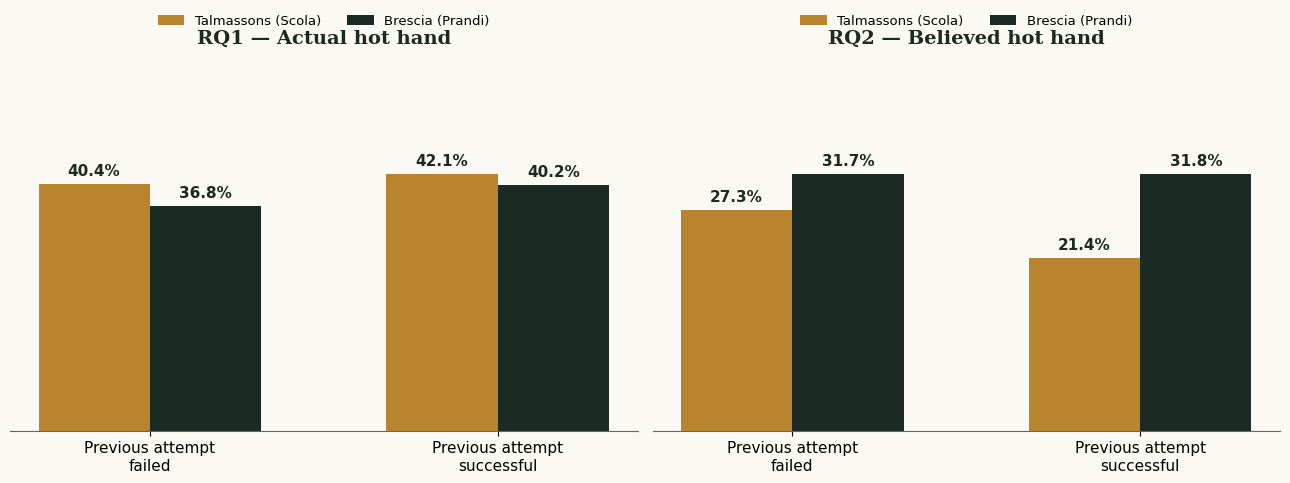

In [29]:
import numpy as np
import matplotlib.pyplot as plt

DARK = "#1B2A22"
ACCENT = "#B8842E"
INK = "#1B2A22"
MUTED = "#5C6B62"

teams = sorted(own.team_name.unique())
team_color = {t: (ACCENT if "Talmassons" in t else DARK) for t in teams}
team_label = {t: ("Talmassons (Scola)" if "Talmassons" in t else "Brescia (Prandi)") for t in teams}

plt.rcParams["font.family"] = "DejaVu Sans"


def styled_grouped_bar(ax, cats, series_vals, title):
    x = np.arange(len(cats))
    width = 0.32
    for i, team in enumerate(teams):
        vals = series_vals[team]
        offset = (i - (len(teams) - 1) / 2) * width
        bars = ax.bar(x + offset, vals, width, label=team_label[team], color=team_color[team], zorder=3)
        for rect, v in zip(bars, vals):
            h = rect.get_height()
            ax.annotate(f"{v:.1%}", (rect.get_x() + rect.get_width() / 2, h),
                        xytext=(0, 4), textcoords="offset points",
                        ha="center", va="bottom", fontsize=11, fontweight="bold", color=INK)
    ax.set_xticks(x)
    ax.set_xticklabels(cats, fontsize=11)
    ax.set_ylim(0, max(v for vals in series_vals.values() for v in vals) * 1.3)
    ax.set_title(title, fontsize=14, fontweight="bold", color=INK, fontfamily="serif", pad=38)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(MUTED)
    ax.tick_params(axis="y", left=False, labelleft=False)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.28), ncol=2, frameon=False, fontsize=9.5)


fig, axes = plt.subplots(1, 2, figsize=(13, 5.1))
fig.patch.set_facecolor("#FAF9F3")
for ax in axes:
    ax.set_facecolor("#FAF9F3")

rq1_vals = {
    team: [rq1[(rq1.team_name == team) & (rq1.prev_success_same_player == 0)].success.mean(),
           rq1[(rq1.team_name == team) & (rq1.prev_success_same_player == 1)].success.mean()]
    for team in teams
}
styled_grouped_bar(axes[0], ["Previous attempt\nfailed", "Previous attempt\nsuccessful"],
                    rq1_vals, "RQ1 — Actual hot hand")

rq2_vals = {
    team: [rq2[(rq2.team_name == team) & (rq2.success == 0)].repeat_target.mean(),
           rq2[(rq2.team_name == team) & (rq2.success == 1)].repeat_target.mean()]
    for team in teams
}
styled_grouped_bar(axes[1], ["Previous attempt\nfailed", "Previous attempt\nsuccessful"],
                    rq2_vals, "RQ2 — Believed hot hand")

plt.tight_layout()
plt.savefig("rq1_rq2_charts.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

## 9. Mixed-effects models for RQ1 and RQ2

The descriptive results provide a first comparison, but attacks cannot be considered independent observations. The same players appear multiple times and have different baseline probabilities of success. Observations also come from different matches, which may have different contexts.

For this reason, RQ1 and RQ2 are analyzed using multilevel logistic regression with random intercepts for player and match.

### RQ1 — Actual hot hand

For RQ1, the outcome is the success of the current attack, while the main predictor is whether the same player's previous attack was successful:

$$\text{logit}[P(\text{success})]=\beta_0 + \beta_1(\text{previous success})+ u_{\text{player}} + u_{\text{match}}$$

Here, $\beta_1$ measures whether a previous success is associated with a higher probability of success on the next attack, while accounting for differences between players and matches.

A positive $\beta_1$ would support the presence of a hot-hand effect.

### RQ2 — Believed hot hand

For RQ2, the outcome is whether the same attacker is selected again on the team's next attack:

$$\text{logit}[P(\text{repeat target})]=\beta_0 + \beta_1(\text{current success})+ u_{\text{player}} + u_{\text{match}}$$

In this case, a positive $\beta_1$ would indicate that an attacker is more likely to be selected again after scoring, which would be consistent with the setter behaving as if she believes in the hot hand.

### Model estimation

Both models include crossed random intercepts for player and match. They are estimated in Python using an iterative procedure implemented with NumPy.

Before using the models on the volleyball data, the implementation is tested on simulated data with known parameters to check that it can recover the expected effects.

In [30]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def fit_glmm_2re(y, X, groups1, groups2, max_iter=300, tol=1e-6):
    # Logistic mixed model with random intercepts for player and match
    # The model is estimated using NumPy only
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    n, p = X.shape

    g1_levels, g1_idx = np.unique(groups1, return_inverse=True)
    g2_levels, g2_idx = np.unique(groups2, return_inverse=True)
    n1, n2 = len(g1_levels), len(g2_levels)

    Z1 = np.zeros((n, n1)); Z1[np.arange(n), g1_idx] = 1.0
    Z2 = np.zeros((n, n2)); Z2[np.arange(n), g2_idx] = 1.0
    Z = np.hstack([Z1, Z2])

    # Start with a standard logistic regression (IRLS)
    beta = np.zeros(p)
    for _ in range(25):
        eta = X @ beta
        mu = sigmoid(eta)
        w = np.clip(mu * (1 - mu), 1e-6, None)
        z_work = eta + (y - mu) / w
        beta_new = np.linalg.solve(X.T @ (X * w[:, None]), X.T @ (w * z_work))
        if np.max(np.abs(beta_new - beta)) < 1e-8:
            beta = beta_new
            break
        beta = beta_new

    u = np.zeros(n1 + n2)
    sigma2_1, sigma2_2 = 1.0, 1.0
    q = n1 + n2

    for it in range(max_iter):
        eta = X @ beta + Z @ u
        mu = sigmoid(eta)
        w = np.clip(mu * (1 - mu), 1e-6, None)
        z_work = eta + (y - mu) / w

        C = np.hstack([X, Z])
        CtWC = C.T @ (C * w[:, None])
        CtWz = C.T @ (w * z_work)

        Dinv_diag = np.concatenate([np.full(n1, 1.0/sigma2_1), np.full(n2, 1.0/sigma2_2)])
        penalty = np.zeros((p + q, p + q))
        idx_re = np.arange(p, p + q)
        penalty[idx_re, idx_re] = Dinv_diag

        LHS_inv = np.linalg.inv(CtWC + penalty)
        sol = LHS_inv @ CtWz
        beta_new, u_new = sol[:p], sol[p:]
        delta = np.max(np.abs(np.concatenate([beta_new, u_new]) - np.concatenate([beta, u])))
        beta, u = beta_new, u_new

        u1, u2 = u[:n1], u[n1:]
        A11 = LHS_inv[np.ix_(np.arange(p, p+n1), np.arange(p, p+n1))]
        A22 = LHS_inv[np.ix_(np.arange(p+n1, p+q), np.arange(p+n1, p+q))]
        # EM M-step: update the variance of each random effect
        sigma2_1_new = max((u1 @ u1 + np.trace(A11)) / n1, 1e-4)
        sigma2_2_new = max((u2 @ u2 + np.trace(A22)) / n2, 1e-4)
        sig_delta = abs(sigma2_1_new - sigma2_1) + abs(sigma2_2_new - sigma2_2)
        sigma2_1, sigma2_2 = sigma2_1_new, sigma2_2_new

        if delta < tol and sig_delta < tol:
            break

    se_beta = np.sqrt(np.diag(LHS_inv)[:p])
    return {'beta': beta, 'se_beta': se_beta, 'u': u, 'sigma2_group1': sigma2_1,
            'sigma2_group2': sigma2_2, 'n_group1': n1, 'n_group2': n2, 'n_iter': it + 1}


# Validation on simulated data with known parameters
_rng = np.random.default_rng(0)
_n_player, _n_match, _obs_per = 15, 40, 400
_player_ids = _rng.integers(0, _n_player, size=_n_player*_obs_per)
_match_ids = _rng.integers(0, _n_match, size=len(_player_ids))
_x = _rng.integers(0, 2, size=len(_player_ids)).astype(float)
_true_beta = np.array([-0.4, 0.35])
_u_p = _rng.normal(0, 0.4, _n_player)
_u_m = _rng.normal(0, 0.25, _n_match)
_eta = _true_beta[0] + _true_beta[1]*_x + _u_p[_player_ids] + _u_m[_match_ids]
_y = _rng.binomial(1, sigmoid(_eta))
_X = np.column_stack([np.ones(len(_x)), _x])

_res = fit_glmm_2re(_y, _X, _player_ids, _match_ids)

print("Validation on simulated data (true beta: [-0.40, 0.35]):")
print(f"Estimated beta = {np.round(_res['beta'], 3)}  (expected close to [-0.40, 0.35])")
print(f"Estimated player variance = {_res['sigma2_group1']:.3f} (true 0.16), "
      f"match variance = {_res['sigma2_group2']:.3f} (true 0.0625)")
print("\nEstimates are consistent with the known parameters.")

Validation on simulated data (true beta: [-0.40, 0.35]):
Estimated beta = [-0.421  0.351]  (expected close to [-0.40, 0.35])
Estimated player variance = 0.065 (true 0.16), match variance = 0.060 (true 0.0625)

Estimates are consistent with the known parameters.


### 9.1 RQ1 — Actual hot hand: player and match random intercepts

In [31]:
from math import erf, sqrt

def significance_stars(p_val):
    if p_val < 0.01:
        return '***'
    elif p_val < 0.05:
        return '**'
    elif p_val < 0.1:
        return '*'
    return ''


def summarize_glmm(df, outcome, predictor, label):
    print(f"{label}\n")
    out = {}
    for team, sub in df.groupby('team_name'):
        y = sub[outcome].to_numpy(dtype=float)
        x = sub[predictor].to_numpy(dtype=float)
        X = np.column_stack([np.ones(len(x)), x])
        res = fit_glmm_2re(y, X, sub['player_name'].to_numpy(), sub['match_id'].to_numpy())
        b, se = res['beta'][1], res['se_beta'][1]
        z = b / se
        p_val = 2 * (1 - 0.5*(1+erf(abs(z)/sqrt(2))))
        stars = significance_stars(p_val)

        print(f"{team}: n={len(sub)} (players={res['n_group1']}, matches={res['n_group2']})")
        print(f"  coefficient (log-odds) = {b:+.3f}{stars}   (SE {se:.3f})")
        print(f"  player variance = {res['sigma2_group1']:.3f}, match variance = {res['sigma2_group2']:.3f}\n")
        out[team] = dict(beta=b, se=se, p=p_val, stars=stars)

    print("Significance: * p<0.1; ** p<0.05; *** p<0.01")
    print()
    return out


rq1_glmm = summarize_glmm(rq1, 'success', 'prev_success_same_player', "RQ1 - Actual hot hand (mixed logistic)")

RQ1 - Actual hot hand (mixed logistic)

CDA Volley Talmassons FVG: n=3436 (players=10, matches=29)
  coefficient (log-odds) = +0.031   (SE 0.071)
  player variance = 0.052, match variance = 0.013

Valsabbina Millenium Brescia: n=4425 (players=12, matches=36)
  coefficient (log-odds) = +0.085   (SE 0.064)
  player variance = 0.106, match variance = 0.010

Significance: * p<0.1; ** p<0.05; *** p<0.01



### 9.2 RQ2 — Believed hot hand: player and match random intercepts

In [32]:
rq2_glmm = summarize_glmm(rq2, 'repeat_target', 'success', "RQ2 - Believed hot hand (mixed logistic)")

RQ2 - Believed hot hand (mixed logistic)

CDA Volley Talmassons FVG: n=3597 (players=10, matches=29)
  coefficient (log-odds) = -0.295***   (SE 0.082)
  player variance = 0.722, match variance = 0.016

Valsabbina Millenium Brescia: n=4650 (players=13, matches=36)
  coefficient (log-odds) = +0.047   (SE 0.067)
  player variance = 0.423, match variance = 0.004

Significance: * p<0.1; ** p<0.05; *** p<0.01



### 9.3 Interpretation

#### RQ1 — Actual hot hand

After accounting for differences between players and matches, neither team shows a statistically significant hot-hand effect.

For Brescia, the effect of a previous success is positive but small ($\beta = 0.085$, SE = 0.064). For Talmassons, it is even closer to zero ($\beta = 0.031$, SE = 0.071). Neither effect is statistically significant.

The player-level variance also confirms that attackers differ in their baseline probability of scoring, supporting the use of a multilevel model.

Overall, there is no evidence that scoring on one attack increases the probability of scoring on the next attack by the same player.

#### RQ2 — Believed hot hand

A different pattern appears for the setter's decision.

For Talmassons, a successful attack has a negative and statistically significant effect on the probability of selecting the same attacker again ($\beta = -0.295$, SE = 0.082, $p < 0.001$). The same attacker is therefore less likely to receive the next set after scoring.

For Brescia, the effect is close to zero and not statistically significant ($\beta = 0.047$, SE = 0.067), showing no clear relationship between success and the next attacking choice.

Overall, there is no evidence of an actual hot-hand effect in either team. For Talmassons, however, there is a significant pattern in ball allocation, but in the opposite direction to a traditional hot-hand belief.

### 9.4 Robustness check — is the RQ2 effect a rotation artefact?

The RQ2 result above is the most behaviourally interesting finding of the project, and for that reason it deserves the strictest test. There is one structural explanation that could produce it without any belief being involved: **rotation**.

A team rotates only when it wins a rally while the opponent is serving (a side-out). A successful attack therefore causes a rotation very often, whereas an unsuccessful one almost never does. Because rotation changes which attackers are in the front row, it also changes who can realistically receive the next set. Success and "the same attacker is still available" are therefore mechanically linked, independently of what the setter believes.

The rotation is identified through the setter's court position, which `pydatavolley` reports for both teams: if it differs between the current attack and the team's next attack, a rotation occurred in between.

Two models are compared on the same sample:

- **Model A** — the specification used above, with `success` as the only fixed effect;
- **Model B** — the same model with `rotated` added as a control.

If the RQ2 effect is behavioural, it should survive in Model B. If it is structural, it should shrink towards zero once rotation is accounted for.

In [33]:
# Rotation marker: the own team's setter position, compared with its value
# on the team's next attack in the same match.
is_home = rq2['team_name'] == rq2['home_team']
rq2['own_setter_pos'] = pd.to_numeric(
    np.where(is_home, rq2['home_setter_position'], rq2['visiting_setter_position']),
    errors='coerce')

rq2 = rq2.sort_values(['team_name', 'match_id', 'seq'])
rq2['next_setter_pos'] = rq2.groupby(['team_name', 'match_id'])['own_setter_pos'].shift(-1)
rq2['rotated'] = (rq2['own_setter_pos'] != rq2['next_setter_pos']).astype(int)

rq2_rot = rq2.dropna(subset=['next_setter_pos']).copy()

print("Rotation before the next attack, by outcome of the current attack")
print(rq2_rot.groupby(['team_name', 'success'])['rotated'].agg(['mean', 'count']))
print()
print("Same attacker chosen again, by rotation status")
print(rq2_rot.groupby(['team_name', 'rotated'])['repeat_target'].agg(['mean', 'count']))

Rotation before the next attack, by outcome of the current attack
                                          mean  count
team_name                    success                 
CDA Volley Talmassons FVG    0        0.144743   2121
                             1        0.693158   1447
Valsabbina Millenium Brescia 0        0.150452   2878
                             1        0.702189   1736

Same attacker chosen again, by rotation status
                                          mean  count
team_name                    rotated                 
CDA Volley Talmassons FVG    0        0.273694   2258
                             1        0.207634   1310
Valsabbina Millenium Brescia 0        0.340311   2962
                             1        0.274213   1652


The descriptive figures already show how strong the link is: a successful attack is followed by a rotation roughly 70% of the time, against about 15% after an unsuccessful one. And when a rotation occurs, the same attacker is chosen again clearly less often. The confounding is therefore not hypothetical — it is present and large.
The two models can now be compared.

In [34]:
def summarize_glmm_multi(df, outcome, predictors, label):
    """Same as summarize_glmm, but reports several fixed effects at once,
    so the effect of interest can be read net of the control variables."""
    print(f"{label}\n")
    out = {}
    for team, sub in df.groupby('team_name'):
        y = sub[outcome].to_numpy(dtype=float)
        X = np.column_stack([np.ones(len(sub))] +
                            [sub[p].to_numpy(dtype=float) for p in predictors])
        res = fit_glmm_2re(y, X, sub['player_name'].to_numpy(), sub['match_id'].to_numpy())

        print(f"{team}: n={len(sub)} (players={res['n_group1']}, matches={res['n_group2']})")
        team_out = {}
        for j, name in enumerate(predictors, start=1):
            b, se = res['beta'][j], res['se_beta'][j]
            z = b / se
            p_val = 2 * (1 - 0.5 * (1 + erf(abs(z) / sqrt(2))))
            st = significance_stars(p_val)
            print(f"  {name:<10} = {b:+.3f}{st}   (SE {se:.3f})")
            team_out[name] = dict(beta=b, se=se, p=p_val, stars=st)
        print(f"  player variance = {res['sigma2_group1']:.3f}, "
              f"match variance = {res['sigma2_group2']:.3f}\n")
        out[team] = team_out

    print("Significance: * p<0.1; ** p<0.05; *** p<0.01")
    print()
    return out


rq2_model_a = summarize_glmm_multi(
    rq2_rot, 'repeat_target', ['success'],
    "Model A - RQ2 without the rotation control (same sample as Model B)")

rq2_model_b = summarize_glmm_multi(
    rq2_rot, 'repeat_target', ['success', 'rotated'],
    "Model B - RQ2 with the rotation control")

Model A - RQ2 without the rotation control (same sample as Model B)

CDA Volley Talmassons FVG: n=3568 (players=10, matches=29)
  success    = -0.283***   (SE 0.082)
  player variance = 0.689, match variance = 0.014

Valsabbina Millenium Brescia: n=4614 (players=13, matches=36)
  success    = +0.043   (SE 0.068)
  player variance = 0.415, match variance = 0.004

Significance: * p<0.1; ** p<0.05; *** p<0.01

Model B - RQ2 with the rotation control

CDA Volley Talmassons FVG: n=3568 (players=10, matches=29)
  success    = -0.142   (SE 0.098)
  rotated    = -0.263***   (SE 0.100)
  player variance = 0.698, match variance = 0.014

Valsabbina Millenium Brescia: n=4614 (players=13, matches=36)
  success    = +0.246***   (SE 0.081)
  rotated    = -0.380***   (SE 0.083)
  player variance = 0.411, match variance = 0.003

Significance: * p<0.1; ** p<0.05; *** p<0.01



#### Interpretation

The comparison changes the conclusion of RQ2.

| Effect of `success` on re-targeting | Model A | Model B (rotation controlled) |
|---|---|---|
| Talmassons (Scola) | −0.283*** | −0.142, n.s. |
| Brescia (Prandi) | +0.043, n.s. | +0.246*** |

**For Talmassons, the effect does not survive.** Once rotation is accounted for, the coefficient loses roughly half its size and its significance. The apparent tendency to move the ball away from an attacker who has just scored is largely explained by the fact that scoring wins the rally, the team rotates, and the attacker is no longer in the same attacking position. This is a mechanical consequence of the rules, not evidence about the setter's beliefs.

**For Brescia, an effect appears that was previously hidden.** In Model A the coefficient is essentially zero; in Model B it is positive and significant. Rotation was masking it: the structural tendency to move away from the previous attacker after a success was cancelling out a genuine tendency of the setter to return to her. Once the two are separated, Prandi *is* more likely to set the same attacker again after a successful attack — which is precisely the believed hot hand that RQ2 set out to detect.

The revised answer to RQ2 is therefore the opposite of the one suggested by the uncontrolled model: the significant behavioural pattern belongs to Brescia, not to Talmassons. Read together with RQ1, which found no real hot-hand effect for either team, this is the clearest form of the dissociation the project was designed to test: Brescia's setter behaves as if a hot hand existed, in a season in which her own attackers' data give no evidence that it does.

This also illustrates a methodological point worth stating explicitly: in observational sport data, the decision being studied and the structure of the game are entangled by the rules themselves. A control that looks like a technical detail — which rotation the team is in — turns out to determine which of two opposite conclusions the data supports.

## 10. RQ3 — Does score pressure change attacking behaviour?

RQ3 investigates whether attacking behaviour changes during the most critical phases of a set.

### Definition of the critical phase

For sets 1–4, an action is classified as critical when at least one team has reached 20 points. The fifth set is considered entirely critical because it is played to 15 points and decides the match.

This variable is constructed using the score and set number already provided by `pydatavolley`.

### RQ3a — Attack errors

The first analysis tests whether the probability of an attack error changes during critical phases.

This is used to examine whether attacking performance becomes more or less error-prone under score pressure.

### RQ3b — Attacking choices

The second analysis tests whether the use of high balls (tempo H) changes during critical phases.
A high ball is not a bolder or a safer attacking choice in the usual sense. Quick and super tempos are in fact easier to convert, because they give the opposing block less time to form; what they require is a clean build-up, and above all a good reception. When the reception or the dig is poor, the setter has no realistic alternative but to put up a high ball and let the attacker face a block that has had time to organise.
High-ball frequency is therefore best read as an indicator of how well the team is handling the contacts that precede the attack — and, indirectly, of whether difficulty or nerves are affecting those contacts — rather than as a measure of attacking caution. Section 10.1 verifies this reading directly on the data before the model is interpreted.

### Statistical approach

Both analyses use the same multilevel logistic regression framework introduced in Section 9, with random intercepts for player and match.

The main predictor is `critical`, which tests whether critical phases are associated with changes in attack errors or high-ball use.

In [35]:
# pydatavolley returns set_number as a string
all_events['critical'] = np.where(
    pd.to_numeric(all_events['set_number'], errors='coerce') == 5,
    True,
    (pd.to_numeric(all_events['home_team_score'], errors='coerce') >= 20) |
    (pd.to_numeric(all_events['visiting_team_score'], errors='coerce') >= 20)
)

attacks_rq3 = own[own.skill == 'Attack'].copy()
attacks_rq3['critical'] = all_events.loc[attacks_rq3.index, 'critical'].astype(int)
attacks_rq3['error'] = (attacks_rq3.evaluation_code == '=').astype(int)
attacks_rq3['is_high_ball'] = (attacks_rq3['tempo_label'] == 'high').astype(int)

print(f"Attacks in critical phases: {attacks_rq3['critical'].sum()} out of {len(attacks_rq3)} ({attacks_rq3['critical'].mean():.1%})")
print()

print("Attack tempo distribution (whole season):")
print(attacks_rq3['tempo_label'].value_counts())
print()

print("Error rate by phase and team")
print(attacks_rq3.groupby(['team_name', 'critical'])['error'].agg(['mean', 'count']))
print()

print("High-ball rate by phase and team")
print(attacks_rq3.groupby(['team_name', 'critical'])['is_high_ball'].agg(['mean', 'count']))

attacks_rq3.to_csv('rq3_attacks.csv', index=False)

Attacks in critical phases: 2273 out of 8312 (27.3%)

Attack tempo distribution (whole season):
tempo_label
super     3102
high      2319
quick     1533
medium     804
other      554
Name: count, dtype: int64

Error rate by phase and team
                                           mean  count
team_name                    critical                 
CDA Volley Talmassons FVG    0         0.075057   2638
                             1         0.071862    988
Valsabbina Millenium Brescia 0         0.069685   3401
                             1         0.050584   1285

High-ball rate by phase and team
                                           mean  count
team_name                    critical                 
CDA Volley Talmassons FVG    0         0.244882   2638
                             1         0.237854    988
Valsabbina Millenium Brescia 0         0.312261   3401
                             1         0.292607   1285


### 10.1 Are high balls a choice, or a consequence?

Before interpreting the high-ball results, it is useful to check how strongly high-ball use depends on the quality of the preceding action. A high ball should not automatically be considered a more conservative attacking choice, since a poor reception may limit the attacking options available to the setter.

The analysis below links each side-out attack to the reception that preceded it in the same rally and calculates the share of high balls for each reception grade.

In [36]:
rec = own[own.skill == 'Reception'][
    ['match_id', 'set_number', 'rally_number', 'team_name', 'evaluation_code', 'seq']
].rename(columns={'evaluation_code': 'rec_eval', 'seq': 'rec_seq'})
rec_first = rec.sort_values('rec_seq').groupby(
    ['match_id', 'set_number', 'rally_number', 'team_name'], as_index=False).first()

atk = own[own.skill == 'Attack'][
    ['match_id', 'set_number', 'rally_number', 'team_name', 'tempo_label', 'seq']]
linked = atk.merge(rec_first, on=['match_id', 'set_number', 'rally_number', 'team_name'])
linked = linked[linked.seq > linked.rec_seq]
sideout = linked.sort_values('seq').groupby(
    ['match_id', 'set_number', 'rally_number', 'team_name'], as_index=False).first()

REC_LABEL = {'#': '# perfect', '+': '+ positive', '!': '! ok',
             '-': '- poor', '/': '/ very poor'}
sideout['rec_grade'] = sideout['rec_eval'].map(REC_LABEL)

print(f"Side-out attacks linked to their own reception: {len(sideout)} "
      f"of {len(own[own.skill == 'Attack'])} own-team attacks")

print("High-ball share by quality of the preceding reception")
hb = sideout.groupby('rec_grade').agg(
    high_ball_share=('tempo_label', lambda s: (s == 'high').mean()),
    n=('tempo_label', 'size')).sort_values('high_ball_share')
print(hb.assign(high_ball_share=lambda d: (d.high_ball_share * 100).round(1)).to_string())

Side-out attacks linked to their own reception: 3811 of 8312 own-team attacks
High-ball share by quality of the preceding reception
             high_ball_share     n
rec_grade                         
# perfect                0.0   887
+ positive               0.1  1597
! ok                     3.7   295
/ very poor             56.8   118
- poor                  59.8   914


The relationship is very strong: after a perfect reception, the team almost never uses a high ball, while after a poor reception the high-ball rate is around 60%. This shows that high-ball use is strongly related to the quality of the preceding action and should not simply be interpreted as a conservative choice under pressure.

The RQ3b coefficient should therefore be interpreted with this relationship in mind. A lower high-ball probability may indicate that the team reaches the attack in better conditions, rather than that it is taking more risks.

This check includes side-out attacks only, since these are preceded by a reception. The remaining attacks occur in transition, after a dig or a freeball, and are therefore not included in this comparison.

### 10.2 Mixed-effects model: player and match random intercepts

In [37]:
err_glmm = summarize_glmm(attacks_rq3, 'error', 'critical', "RQ3a - Error : critical phase")
hb_glmm = summarize_glmm(attacks_rq3, 'is_high_ball', 'critical', "RQ3b - High ball : critical phase")

RQ3a - Error : critical phase

CDA Volley Talmassons FVG: n=3626 (players=10, matches=29)
  coefficient (log-odds) = -0.046   (SE 0.144)
  player variance = 0.039, match variance = 0.009

Valsabbina Millenium Brescia: n=4686 (players=13, matches=36)
  coefficient (log-odds) = -0.358**   (SE 0.145)
  player variance = 0.060, match variance = 0.008

Significance: * p<0.1; ** p<0.05; *** p<0.01

RQ3b - High ball : critical phase

CDA Volley Talmassons FVG: n=3626 (players=10, matches=29)
  coefficient (log-odds) = -0.112   (SE 0.094)
  player variance = 7.024, match variance = 0.042

Valsabbina Millenium Brescia: n=4686 (players=13, matches=36)
  coefficient (log-odds) = -0.190**   (SE 0.078)
  player variance = 8.380, match variance = 0.038

Significance: * p<0.1; ** p<0.05; *** p<0.01



### 10.3 Interpretation

For Talmassons, there is no statistically significant difference between normal and critical phases. The effects are small and non-significant for both attack errors ($\beta = -0.046$, SE = 0.144) and high-ball use ($\beta = -0.112$, SE = 0.094). Overall, Talmassons appears relatively stable under score pressure.

For Brescia, both coefficients are significant and negative. The probability of an attack error is lower in critical phases ($\beta = -0.358$, SE = 0.145, $p < 0.05$), and the probability of using a high ball is also lower ($\beta = -0.190$, SE = 0.078, $p < 0.05$).

Considering the strong relationship between high-ball use and the quality of the preceding actions shown in Section 10.1, the lower high-ball probability should not simply be interpreted as Brescia taking more risks. Instead, it is consistent with the team reaching the attack in better conditions during critical phases.

There is therefore no evidence of worse attacking performance under score pressure in this dataset. Brescia shows fewer attack errors and lower high-ball use during critical phases, a pattern that may be consistent with better performance under pressure.

One possible explanation is that the quality of the build-up improves in critical phases. Positive reception increases slightly from 56.2% to 57.9%, but this difference is not statistically significant. In addition, high-ball use can also depend on defensive contacts during transition. The mechanism is therefore consistent with the data but cannot be established from the current analysis.


**Note on the large player-level variance in RQ3b:** The variance of the player random intercept is much higher for high-ball use than for the other models. This is mainly related to player role: for example, middle blockers rarely attack on high balls. The random intercept accounts for these baseline differences between players. The coefficient on `critical` can therefore be interpreted as a within-player effect: for the same attacker, high-ball use is lower during critical phases.

## 11. Limitations and Possible Extensions

The analysis has some limitations that could be addressed in future work:

- **Rotation:** Section 9.4 shows that rotation is important for RQ2. The current control is binary, indicating only whether a rotation occurred. A possible extension would include the attacker's actual rotational position, distinguishing between front-row and back-row situations.

- **Definition of success:** success is defined only as a winning attack (`#`). A robustness check could also include positive attacks (`+`) to test whether the results depend on this definition.

- **Longer attack sequences:** RQ1 considers only the immediately previous attack. Future analyses could examine longer sequences to study whether hot-hand patterns emerge over multiple attempts.

- **Model validation:** the mixed-effects estimator could be compared with an established implementation as an additional validation check.

- **Player-specific effects of pressure:** RQ3 estimates an overall effect of critical phases. A possible extension would test whether the effect of pressure differs across players.

- **Build-up quality:** Section 10.1 shows a strong relationship between reception quality and high-ball use. Future analyses could model reception and dig quality directly to investigate whether build-up quality helps explain the relationship between competitive pressure and attacking situation.